In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from IPython.core.pylabtools import figsize

sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config
from utils_energy_analysis import *

In [2]:
model = 'geneva_2025'
mitgcm_config, ds = open_mitgcm_ds_from_config('..//config.json', model)

In [3]:
folder_path = os.path.dirname(mitgcm_config['datapath'])
output_folder = os.path.join(folder_path, "figures", "isotherm_map")
os.makedirs(output_folder, exist_ok=True)

In [4]:
grid_resolution = 100
ds['YC'] = np.arange(1, len(ds['YC']) + 1) * grid_resolution - grid_resolution / 2
ds['XC'] = np.arange(1, len(ds['XC']) + 1) * grid_resolution - grid_resolution / 2
ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

### Task (more specific)
Compute, for a single time slice (default: last timestep), the 2D field **z(x,y)** where **THETA(z,x,y) = 13°C** by finding the first vertical crossing and linearly interpolating between the two surrounding Z-levels, then plot it as a map and save it to `output_folder`.

In [5]:
target_T = 13.0
time_index = -1
theta_3d = ds["THETA"].isel(time=time_index)
Z = ds["Z"]

### Task (more specific)
Recompute the **13°C isotherm** using a robust first-vertical sign-change detection (surface → bottom) and then **convert negative Z (depth below surface)** into a **positive depth** field (`depth = -Z`) for plotting/saving.

In [6]:
t_corr = theta_3d - target_T

t_next = t_corr.shift(Z=-1)
z_next = Z.shift(Z=-1)

valid_pair = np.isfinite(t_corr) & np.isfinite(t_next) & np.isfinite(Z) & np.isfinite(z_next)
sign_change = valid_pair & (t_corr == 0) | (valid_pair & (t_corr * t_next < 0))

has_cross_corr = sign_change.any("Z")

k_corr = sign_change.argmax("Z").astype(np.int64)
k0_corr = xr.where(has_cross_corr, k_corr, 0).astype(np.int64).compute()
k1_corr = xr.where((has_cross_corr) & (k0_corr < (Z.size - 1)), k0_corr + 1, k0_corr).astype(np.int64).compute()

t0_corr = t_corr.isel(Z=k0_corr)
t1_corr = t_corr.isel(Z=k1_corr)
z0_corr = Z.isel(Z=k0_corr)
z1_corr = Z.isel(Z=k1_corr)

z_iso_corr = z0_corr + (0.0 - t0_corr) * (z1_corr - z0_corr) / (t1_corr - t0_corr)
z_iso_corr = z_iso_corr.where(has_cross_corr & np.isfinite(z_iso_corr))
z_iso_corr.name = "z_isotherm_13C"

depth_iso_corr = (-z_iso_corr).where(has_cross_corr)
depth_iso_corr.name = "depth_isotherm_13C"

/home/leroquan@eawag.wroot.emp-eaw.ch/miniconda3/envs/horizontal_structures/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/leroquan@eawag.wroot.emp-eaw.ch/miniconda3/envs/horizontal_structures/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


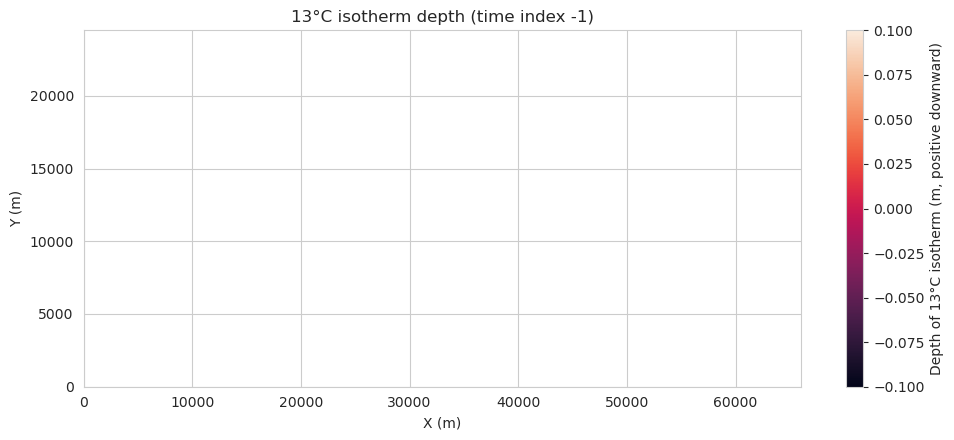

'/storage/alplakes_test/geneva_100m_2025/figures/isotherm_map/isotherm_13C_depth_pos_t-1.png'

In [7]:
fig = plt.figure(figsize=(10, 4.5))
m = plt.pcolormesh(ds["XC"], ds["YC"], depth_iso_corr, shading="auto")
plt.colorbar(m, label="Depth of 13°C isotherm (m, positive downward)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title(f"13°C isotherm depth (time index {time_index})")
plt.tight_layout()

out_path_corr = os.path.join(output_folder, f"isotherm_13C_depth_pos_t{time_index}.png")
plt.savefig(out_path_corr, dpi=200)
plt.show()
out_path_corr
